# 04. Affordability Scenarios

This notebook analyzes housing affordability in Barcelona by combining listing prices with local income estimates.

The objective is to estimate the mortgage burden associated with listed flats under explicit financing assumptions and compare affordability across districts and neighborhoods.

The analysis is scenario-based. It does not attempt to predict actual mortgage approvals or household decisions, but provides a structured view of affordability pressure using consistent assumptions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.paths import PROCESSED_DIR, EXTERNAL_DIR, FIGURES_DIR
from src.analysis.affordability import (
    DEFAULT_SALARY_ADJUSTMENTS,
    DEFAULT_MORTGAGE_ASSUMPTIONS,
    load_salary_data,
    adjust_salary_values,
    fetch_census_section_geometries,
    merge_salaries_with_census_geometries,
    attach_salary_to_listings,
    calculate_financed_amount,
    calculate_annual_payment_linear,
    find_minimum_affordable_years,
    add_mortgage_duration_metrics,
    add_fixed_term_burden_metrics,
    summarize_affordability_by_area,
    fetch_neighborhood_geometries,
    merge_geometries_with_summary,
    create_affordability_choropleth,
)

## 1. Load listing data

This module uses the processed listing dataset generated in the market snapshot module.

In [3]:
df = pd.read_csv(PROCESSED_DIR / "listings_processed.csv")
# df.head()
print(df.shape)

(4438, 96)


## 2. Load and prepare salary data

The income data is available at census-section level. This level of granularity allows each listing to be linked to a local income estimate based on its geographic position.

Because the salary data refers to an earlier period, the values are adjusted using explicit scenario assumptions.

In [4]:
salary_path = EXTERNAL_DIR / "30896.csv"

salaries = load_salary_data(salary_path)
salaries_adjusted = adjust_salary_values(salaries, adjustments=DEFAULT_SALARY_ADJUSTMENTS,)

salaries_adjusted.head()

,Municipios,Distritos,Secciones,Indicadores de renta media y mediana,Periodo,Total
0,08001 Abrera,0800101 Abrera distrito 01,0800101001,Renta neta media por persona,2021,21940.770834
1,08001 Abrera,0800101 Abrera distrito 01,0800101002,Renta neta media por persona,2021,21197.092905
2,08001 Abrera,0800101 Abrera distrito 01,0800101003,Renta neta media por persona,2021,27670.574511
3,08001 Abrera,0800101 Abrera distrito 01,0800101004,Renta neta media por persona,2021,24489.874611
4,08001 Abrera,0800101 Abrera distrito 01,0800101005,Renta neta media por persona,2021,21403.081089


In [5]:
pd.DataFrame({"Assumption": list(DEFAULT_SALARY_ADJUSTMENTS.keys()), "Value": list(DEFAULT_SALARY_ADJUSTMENTS.values())})

,Assumption,Value
0,inflation_2022,0.084
1,inflation_2023,0.035
2,salary_alignment_adjustment,0.350


The **salary inflation adjustment** is treated as a scenario assumption rather than an observed fact.

This preserves census-section granularity while approximating a more recent income level. The adjustment should be interpreted carefully, especially when comparing areas with different income profiles.

## 3. Attach salary estimates to listings

Each listing is spatially joined to the census section where it is located. The listing then inherits the adjusted salary estimate for that census section.

In [6]:
census_geo_df = fetch_census_section_geometries()
geo_salaries = merge_salaries_with_census_geometries(census_geo_df=census_geo_df, salaries=salaries_adjusted)
display(geo_salaries.head())

gdf_flats_with_salaries = attach_salary_to_listings(listings_df=df, geo_salaries=geo_salaries,)
gdf_flats_with_salaries.shape

,nom_districte,nom_barri,geometry,census_section_code,salary
0,Ciutat Vella,el Raval,"POLYGON ((2.17575 41.37827, 2.17552 41.37865, ...",0801901001,16912.235754
1,Ciutat Vella,el Raval,"POLYGON ((2.1751 41.37905, 2.1747 41.37951, 2....",0801901002,13805.752185
2,Ciutat Vella,el Raval,"POLYGON ((2.1722 41.37692, 2.17206 41.37696, 2...",0801901003,14284.371789
3,Ciutat Vella,el Raval,"POLYGON ((2.16962 41.37847, 2.16962 41.37847, ...",0801901004,16506.317862
4,Ciutat Vella,el Raval,"POLYGON ((2.17366 41.38071, 2.1733 41.38113, 2...",0801901005,14717.552823


(4438, 102)

In [7]:
gdf_flats_with_salaries[["value","surface","level7","level8","salary","census_section_code"]].head()

,value,surface,level7,level8,salary,census_section_code
0,475000,92,Eixample,La Nova Esquerra de l'Eixample,31108.759641,0801902120
1,655000,103,Eixample,L'Antiga Esquerra de l'Eixample,29678.959305,0801902101
2,395000,53,Eixample,La Nova Esquerra de l'Eixample,26829.960966,0801902135
3,495000,110,Ciutat Vella,Barri Gòtic,17575.638876,0801901031
4,226000,81,Nou Barris,Vilapicina i la Torre Llobeta,23185.787652,0801908003


## 4. Mortgage assumptions

The affordability calculations are based on explicit mortgage assumptions.

The analysis considers:

- purchase costs added to the property price
- an initial down payment
- an annual interest rate
- a maximum share of salary allocated to mortgage payments
- single-person and couple income scenarios
- a fixed 30-year mortgage scenario

The mortgage calculation uses a simplified linear principal repayment model. In this model, principal is repaid evenly over the mortgage duration and interest is calculated on the remaining balance.

In [8]:
pd.DataFrame({"Assumption": list(DEFAULT_MORTGAGE_ASSUMPTIONS.keys()), "Value": list(DEFAULT_MORTGAGE_ASSUMPTIONS.values()),})

,Assumption,Value
0,purchase_cost_rate,0.105
1,down_payment_rate,0.200
2,annual_interest_rate,0.030
3,affordability_threshold,0.350
4,fixed_mortgage_years,30.000
5,max_mortgage_years,120.000


## 5. Mortgage calculation example

This section validates the mortgage calculation with a single example before applying it to all listings.

In [9]:
example_property_price = 475_000
example_salary = 50_000
example_interest_rate = DEFAULT_MORTGAGE_ASSUMPTIONS["annual_interest_rate"]

example_financed_amount = calculate_financed_amount(example_property_price)

example_minimum_affordable = find_minimum_affordable_years(
    property_price=example_property_price,
    annual_salary=example_salary,
    annual_interest_rate=example_interest_rate,
)

example_fixed_annual_payment = calculate_annual_payment_linear(
    property_price=example_property_price,
    n_years=30,
    annual_interest_rate=example_interest_rate,
)

pd.DataFrame({
    "Metric": [
        "Property asking price",
        "Financed amount after costs and down payment",
        "Annual salary",
        "Minimum affordable mortgage years",
        "Annual payment at minimum affordable duration",
        "Annual payment for 30-year mortgage",
    ],
    "Value": [
        example_property_price,
        example_financed_amount,
        example_salary,
        example_minimum_affordable["years_mortgage"],
        example_minimum_affordable["annual_payment"],
        example_fixed_annual_payment,
    ],
})

,Metric,Value
0,Property asking price,475000.000000
1,Financed amount after costs and down payment,429875.000000
2,Annual salary,50000.000000
3,Minimum affordable mortgage years,40.000000
4,Annual payment at minimum affordable duration,17356.203125
5,Annual payment for 30-year mortgage,20992.229167


## 6. Minimum affordable mortgage duration

For each listing, the analysis estimates the minimum mortgage duration required for the annual mortgage payment to remain below the affordability threshold.

Two scenarios are calculated:

- single-person income
- couple income, assuming two people with the same local salary estimate

In [10]:
gdf_flats_with_salaries = add_mortgage_duration_metrics(
    gdf_flats_with_salaries,
    annual_interest_rate=DEFAULT_MORTGAGE_ASSUMPTIONS["annual_interest_rate"],
    affordability_threshold=DEFAULT_MORTGAGE_ASSUMPTIONS["affordability_threshold"],
    max_years=DEFAULT_MORTGAGE_ASSUMPTIONS["max_mortgage_years"],
)

gdf_flats_with_salaries[
    [
        "value",
        "salary",
        "years_mortgage",
        "years_mortgage_couple",
        "total_mortgage_amount",
        "total_mortgage_amount_couple",
    ]
].head()

,value,salary,years_mortgage,years_mortgage_couple,total_mortgage_amount,total_mortgage_amount_couple
0,475000,31108.759641,99.0,29.0,1074687.50,623318.750
1,655000,29678.959305,NaN,51.0,NaN,1055139.500
2,395000,26829.960966,91.0,28.0,850790.50,512976.625
3,495000,17575.638876,NaN,82.0,NaN,1005703.875
4,226000,23185.787652,42.0,16.0,336451.85,256685.150


In [11]:
overall_duration_summary = pd.DataFrame({
    "Scenario": ["Single income", "Couple income"],
    "Average minimum mortgage years": [
        gdf_flats_with_salaries["years_mortgage"].mean(),
        gdf_flats_with_salaries["years_mortgage_couple"].mean(),
    ],
    "Median minimum mortgage years": [
        gdf_flats_with_salaries["years_mortgage"].median(),
        gdf_flats_with_salaries["years_mortgage_couple"].median(),
    ],
})

overall_duration_summary

,Scenario,Average minimum mortgage years,Median minimum mortgage years
0,Single income,62.115211,59.0
1,Couple income,35.797376,28.0


The affordability duration analysis shows a strong gap between single-income and couple-income scenarios.

Under the defined assumptions, the average minimum mortgage duration is approximately 62 years for a single-income scenario and 36 years for a couple-income scenario. The median values are 59 and 28 years respectively.

This indicates that, for a large share of listings, affordability is highly constrained under a single-income profile. The couple-income scenario improves affordability substantially, but still implies long mortgage horizons for many properties.

## 7. Affordability by district and neighborhood

The listing-level affordability metrics are aggregated by district and neighborhood to compare spatial affordability patterns.

In [24]:
district_affordability = summarize_affordability_by_area(gdf_flats_with_salaries, area_col="level7")
district_affordability.sort_values("mean_years_mortgage", ascending=False).reset_index(drop=True)

,level7,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple,mean_salary_burden,median_salary_burden,mean_salary_burden_couple,median_salary_burden_couple
0,Sarrià - Sant Gervasi,390,779571.394872,760000.0,38387.130809,38010.878424,74.255319,75.0,46.551351,40.5,0.900192,0.873925,0.450096,0.436962
1,Eixample,1012,607107.551383,550000.0,30285.517818,29940.988392,72.380631,74.0,42.900969,33.0,0.880779,0.789210,0.440390,0.394605
2,Gràcia,302,523886.678808,470000.0,28585.394356,28576.316673,67.613924,67.0,35.802867,29.0,0.808222,0.706682,0.404111,0.353341
3,Ciutat Vella,730,436230.173973,360000.0,18471.942679,18825.199551,65.962406,63.5,41.746552,35.0,1.040800,0.868897,0.520400,0.434449
4,Les Corts,201,620701.990050,530000.0,35376.766656,34659.026577,59.915094,58.5,36.435897,30.0,0.755772,0.690657,0.377886,0.345328
5,Sant Martí,529,411969.790170,345000.0,25129.945114,24370.219710,58.903509,54.0,31.634000,25.0,0.710747,0.617021,0.355373,0.308511
6,Sants - Montjuïc,411,300098.408759,280000.0,22321.381967,22292.162442,58.585139,56.0,25.745050,22.0,0.600405,0.553932,0.300203,0.276966
7,Sant Andreu,240,330817.416667,299000.0,23122.350360,24279.342570,57.590643,52.0,28.075314,23.0,0.622107,0.578440,0.311053,0.289220
8,Horta - Guinardó,337,343868.261128,314800.0,23535.287110,23675.009589,52.346491,48.0,30.620896,22.0,0.640658,0.557904,0.320329,0.278952
9,Nou Barris,286,217458.409091,199000.0,18924.640114,18616.182129,51.773077,43.0,20.245614,17.0,0.500543,0.457294,0.250272,0.228647


Affordability pressure varies significantly across districts.

Sarrià - Sant Gervasi and Eixample show the highest average minimum mortgage durations, driven by high listing prices despite having higher local salaries. Ciutat Vella also shows high affordability pressure, but for a different reason: average prices are lower than in premium districts, while local salaries are also substantially lower.

Nou Barris, Horta - Guinardó, Sant Andreu, and Sants - Montjuïc show lower average mortgage durations, reflecting lower listing prices relative to local income levels.

This confirms that affordability is not determined by price alone. It depends on the interaction between listing prices, local income estimates, and financing assumptions.

In [17]:
neighborhood_affordability = summarize_affordability_by_area(gdf_flats_with_salaries,area_col="level8")
neighborhood_affordability.sort_values("mean_years_mortgage",ascending=False).reset_index(drop=True).head(10)

,level8,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple
0,Pedralbes,54,9.191852e+05,848000.0,41444.435552,44541.915552,91.181818,104.0,50.640000,47.5
1,Vallbona,2,2.170000e+05,217000.0,15346.119708,15346.119708,86.500000,86.5,26.500000,26.5
2,Vallcarca i els Penitents,22,7.092273e+05,599500.0,30058.371365,30010.660866,86.000000,87.5,36.812500,33.0
3,La Clota,6,4.831667e+05,512000.0,21687.829461,21687.829461,85.000000,85.0,54.166667,57.5
4,Sant Antoni,86,5.055500e+05,435000.0,27462.367234,27226.791144,79.086957,86.0,40.047619,30.0
5,Les Tres Torres,24,1.032125e+06,1062500.0,45360.882667,47648.399121,78.750000,72.5,56.304348,54.0
6,Diagonal Mar i el Front Marítim del Poblenou,82,6.773293e+05,647200.0,29641.710897,31181.461353,78.346154,78.0,51.760563,45.0
7,Sant Gervasi- Galvany,177,7.651587e+05,750000.0,39684.928285,38946.912966,76.771429,72.0,43.901734,38.0
8,El Putget i el Farró,77,7.056059e+05,685000.0,34784.503909,34543.915533,75.828571,75.0,44.457143,32.0
9,Barri Gòtic,228,5.823943e+05,534000.0,19994.531920,20199.716294,73.500000,77.0,53.240000,49.0


In [18]:
neighborhood_affordability.sort_values("mean_years_mortgage",ascending=True).reset_index(drop=True).head(10)

,level8,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple
0,Ciutat Meridiana,17,111952.941176,106000.0,13278.041106,13519.489194,33.823529,34.0,13.705882,14.0
1,Can Peguera,1,154000.000000,154000.0,16677.469809,16677.469809,38.000000,38.0,15.000000,15.0
2,El Carmel,44,219108.636364,182000.0,18643.892772,18434.427849,38.428571,38.0,23.068182,16.0
3,La Trinitat Nova,4,144250.000000,165000.0,15627.081533,16061.777186,39.000000,45.5,15.000000,17.0
4,Montbau,3,399000.000000,239000.0,22563.784116,22178.566017,39.000000,39.0,15.000000,15.0
5,La Font d'en Fargues,26,471192.307692,527500.0,29922.871219,30153.035052,39.666667,39.5,34.923077,35.5
6,Verdum,20,170915.000000,157500.0,17217.734406,16780.463901,39.789474,36.0,17.100000,15.5
7,La Teixonera,44,238655.681818,190000.0,20366.048998,20209.561317,40.405405,37.0,24.795455,16.0
8,Torre Baró,7,168671.428571,135500.0,15151.166605,15246.154854,40.500000,30.5,22.285714,14.0
9,La Vila Olímpica del Poblenou,28,600603.571429,665000.0,35516.138650,35731.376829,41.583333,30.5,35.444444,36.0


At neighborhood level, the highest mortgage durations are concentrated in areas where high listing prices are not fully offset by local income levels.

Pedralbes, Vallcarca i els Penitents, Les Tres Torres, Diagonal Mar i el Front Marítim del Poblenou, Sant Gervasi - Galvany, and El Putget i el Farró appear among the areas with the longest mortgage horizons.

## 8. Fixed 30-year mortgage burden

This section estimates what share of annual salary would be required to pay for each listing under a fixed 30-year mortgage scenario.

The burden is calculated as:

`annual mortgage payment / annual salary`

The calculation is performed for both single-person and couple-income scenarios.

In [20]:
gdf_flats_with_salaries = add_fixed_term_burden_metrics(
    gdf_flats_with_salaries,
    n_years=DEFAULT_MORTGAGE_ASSUMPTIONS["fixed_mortgage_years"],
    annual_interest_rate=DEFAULT_MORTGAGE_ASSUMPTIONS["annual_interest_rate"],
)

gdf_flats_with_salaries[["value","salary","annual_payment_30y","salary_burden_30y","salary_burden_30y_couple"]].head()

,value,salary,annual_payment_30y,salary_burden_30y,salary_burden_30y_couple
0,475000,31108.759641,20992.229167,0.674801,0.337401
1,655000,29678.959305,28947.179167,0.975343,0.487672
2,395000,26829.960966,17456.695833,0.650642,0.325321
3,495000,17575.638876,21876.112500,1.244684,0.622342
4,226000,23185.787652,9987.881667,0.430776,0.215388


In [21]:
overall_burden_summary = pd.DataFrame({
    "Scenario": ["Single income", "Couple income"],
    "Average salary burden": [
        gdf_flats_with_salaries["salary_burden_30y"].mean(),
        gdf_flats_with_salaries["salary_burden_30y_couple"].mean(),
    ],
    "Median salary burden": [
        gdf_flats_with_salaries["salary_burden_30y"].median(),
        gdf_flats_with_salaries["salary_burden_30y_couple"].median(),
    ],
})

overall_burden_summary

,Scenario,Average salary burden,Median salary burden
0,Single income,0.795423,0.684221
1,Couple income,0.397712,0.342110


The fixed 30-year mortgage scenario shows that the average salary burden is approximately 80% of annual income for a single-income profile and approximately 40% for a couple-income profile.

The median burden is lower, around 68% for a single-income profile and 34% for a couple-income profile, indicating that the distribution is affected by a high-burden tail.

Compared with the 35% affordability threshold, the median couple-income scenario is close to the affordability boundary, while the single-income scenario remains clearly above it.

In [25]:
district_affordability = summarize_affordability_by_area(gdf_flats_with_salaries,area_col="level7")
district_affordability.sort_values("mean_salary_burden",ascending=False).reset_index(drop=True)

,level7,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple,mean_salary_burden,median_salary_burden,mean_salary_burden_couple,median_salary_burden_couple
0,Ciutat Vella,730,436230.173973,360000.0,18471.942679,18825.199551,65.962406,63.5,41.746552,35.0,1.040800,0.868897,0.520400,0.434449
1,Sarrià - Sant Gervasi,390,779571.394872,760000.0,38387.130809,38010.878424,74.255319,75.0,46.551351,40.5,0.900192,0.873925,0.450096,0.436962
2,Eixample,1012,607107.551383,550000.0,30285.517818,29940.988392,72.380631,74.0,42.900969,33.0,0.880779,0.789210,0.440390,0.394605
3,Gràcia,302,523886.678808,470000.0,28585.394356,28576.316673,67.613924,67.0,35.802867,29.0,0.808222,0.706682,0.404111,0.353341
4,Les Corts,201,620701.990050,530000.0,35376.766656,34659.026577,59.915094,58.5,36.435897,30.0,0.755772,0.690657,0.377886,0.345328
5,Sant Martí,529,411969.790170,345000.0,25129.945114,24370.219710,58.903509,54.0,31.634000,25.0,0.710747,0.617021,0.355373,0.308511
6,Horta - Guinardó,337,343868.261128,314800.0,23535.287110,23675.009589,52.346491,48.0,30.620896,22.0,0.640658,0.557904,0.320329,0.278952
7,Sant Andreu,240,330817.416667,299000.0,23122.350360,24279.342570,57.590643,52.0,28.075314,23.0,0.622107,0.578440,0.311053,0.289220
8,Sants - Montjuïc,411,300098.408759,280000.0,22321.381967,22292.162442,58.585139,56.0,25.745050,22.0,0.600405,0.553932,0.300203,0.276966
9,Nou Barris,286,217458.409091,199000.0,18924.640114,18616.182129,51.773077,43.0,20.245614,17.0,0.500543,0.457294,0.250272,0.228647


The 30-year salary burden analysis provides a more direct view of affordability pressure.

Ciutat Vella shows the highest average burden, exceeding 100% of annual income in the single-income scenario. This is mainly explained by the combination of moderate-to-high listing prices and comparatively low local salary estimates.

Sarrià - Sant Gervasi and Eixample also show high burden levels, primarily driven by elevated listing prices. In contrast, Nou Barris, Sants - Montjuïc, Sant Andreu, and Horta - Guinardó show lower average burdens.

The couple-income scenario reduces the burden by half, but several districts still remain above or close to the 35% affordability threshold.

In [27]:
neighborhood_affordability = summarize_affordability_by_area(gdf_flats_with_salaries,area_col="level8")
neighborhood_affordability.sort_values("mean_salary_burden",ascending=False).reset_index(drop=True).head(10)

,level8,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple,mean_salary_burden,median_salary_burden,mean_salary_burden_couple,median_salary_burden_couple
0,Barri Gòtic,228,5.823943e+05,534000.0,19994.531920,20199.716294,73.500000,77.0,53.240000,49.0,1.310959,1.132076,0.655480,0.566038
1,"Sant Pere, Sta. Caterina i la Ribera",183,4.935978e+05,427000.0,20936.628097,20135.344986,70.430556,70.5,42.123188,32.0,1.056338,0.914647,0.528169,0.457324
2,Sant Gervasi i la Bonanova,60,8.717333e+05,860000.0,37839.903183,38322.889938,64.000000,69.5,54.115385,59.5,1.040016,1.110330,0.520008,0.555165
3,Vallcarca i els Penitents,22,7.092273e+05,599500.0,30058.371365,30010.660866,86.000000,87.5,36.812500,33.0,1.034693,0.889460,0.517346,0.444730
4,Dreta de l'Eixample,277,7.814061e+05,785000.0,33640.765174,33845.676174,71.133333,70.0,54.252066,52.0,1.030876,1.039890,0.515438,0.519945
5,Les Tres Torres,24,1.032125e+06,1062500.0,45360.882667,47648.399121,78.750000,72.5,56.304348,54.0,1.019097,1.026833,0.509548,0.513417
6,Diagonal Mar i el Front Marítim del Poblenou,82,6.773293e+05,647200.0,29641.710897,31181.461353,78.346154,78.0,51.760563,45.0,1.012716,0.990708,0.506358,0.495354
7,Pedralbes,54,9.191852e+05,848000.0,41444.435552,44541.915552,91.181818,104.0,50.640000,47.5,0.989487,0.969096,0.494743,0.484548
8,La Clota,6,4.831667e+05,512000.0,21687.829461,21687.829461,85.000000,85.0,54.166667,57.5,0.984568,1.043323,0.492284,0.521662
9,La Marina del Prat Vermell,18,3.911611e+05,378875.0,18975.651705,17875.533438,49.500000,49.5,48.777778,44.5,0.917007,0.901287,0.458503,0.450643


In [28]:
neighborhood_affordability.sort_values("mean_salary_burden",ascending=True).reset_index(drop=True).head(10)

,level8,listing_count,mean_price,median_price,mean_salary,median_salary,mean_years_mortgage,median_years_mortgage,mean_years_mortgage_couple,median_years_mortgage_couple,mean_salary_burden,median_salary_burden,mean_salary_burden_couple,median_salary_burden_couple
0,Ciutat Meridiana,17,111952.941176,106000.0,13278.041106,13519.489194,33.823529,34.0,13.705882,14.0,0.371223,0.375926,0.185612,0.187963
1,La Trinitat Nova,4,144250.000000,165000.0,15627.081533,16061.777186,39.000000,45.5,15.000000,17.0,0.403071,0.454013,0.201535,0.227007
2,Can Peguera,1,154000.000000,154000.0,16677.469809,16677.469809,38.000000,38.0,15.000000,15.0,0.408090,0.408090,0.204045,0.204045
3,Canyelles,4,212125.000000,212250.0,21611.719856,21832.475576,42.250000,42.0,16.250000,16.0,0.433911,0.433228,0.216956,0.216614
4,Verdum,20,170915.000000,157500.0,17217.734406,16780.463901,39.789474,36.0,17.100000,15.5,0.439038,0.406835,0.219519,0.203418
5,Les Roquetes,49,161393.877551,140000.0,15847.644061,15518.786274,43.159091,32.5,18.204082,16.0,0.449662,0.415047,0.224831,0.207523
6,Trinitat Vella,19,160268.421053,142000.0,15456.368028,14487.330735,43.941176,41.0,19.105263,16.0,0.472927,0.431607,0.236463,0.215803
7,Baró de Viver,1,159990.000000,159990.0,14647.880349,14647.880349,50.000000,50.0,19.000000,19.0,0.482706,0.482706,0.241353,0.241353
8,La Guineueta,20,259395.000000,245000.0,23405.937524,22882.106542,48.555556,38.5,19.700000,16.5,0.488281,0.427711,0.244140,0.213855
9,Torre Baró,7,168671.428571,135500.0,15151.166605,15246.154854,40.500000,30.5,22.285714,14.0,0.490161,0.390217,0.245080,0.195108


The neighborhood-level salary burden ranking highlights the areas where a standard 30-year mortgage would require the largest share of local income.

Barri Gòtic, Sant Pere, Sta. Caterina i la Ribera, Sant Gervasi i la Bonanova, Vallcarca i els Penitents, Dreta de l'Eixample, Les Tres Torres, Diagonal Mar i el Front Marítim del Poblenou, and Pedralbes appear among the highest-burden neighborhoods.

The drivers are not identical across neighborhoods. In some areas, the burden is mainly driven by very high listing prices. In others, such as parts of Ciutat Vella, the burden is amplified by lower local salary estimates.

## 9. Affordability distributions

The following plots summarize the distribution of affordability indicators across listings.

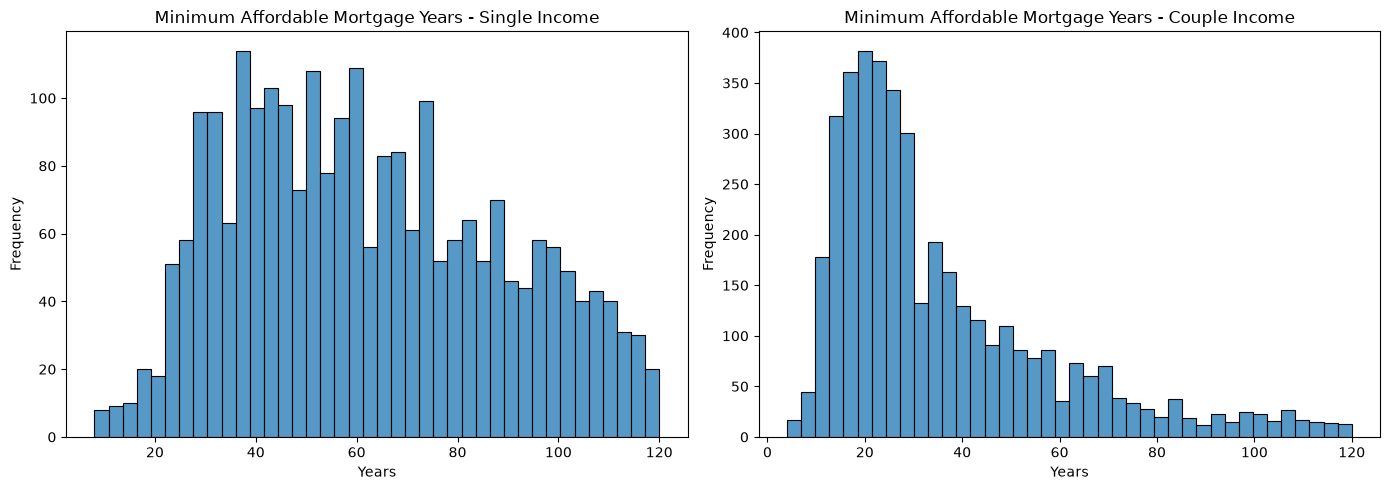

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(gdf_flats_with_salaries["years_mortgage"].dropna(),bins=40,ax=axes[0])

axes[0].set_title("Minimum Affordable Mortgage Years - Single Income")
axes[0].set_xlabel("Years")
axes[0].set_ylabel("Frequency")

sns.histplot(gdf_flats_with_salaries["years_mortgage_couple"].dropna(),bins=40,ax=axes[1])

axes[1].set_title("Minimum Affordable Mortgage Years - Couple Income")
axes[1].set_xlabel("Years")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The distribution of minimum affordable mortgage years shows that single-income affordability is highly constrained across the listing market.

For single-income scenarios, many listings require mortgage durations far above conventional mortgage terms. In contrast, the couple-income distribution shifts substantially toward shorter durations, although a long right tail remains.

This indicates that household composition is a critical driver of affordability under the defined assumptions.

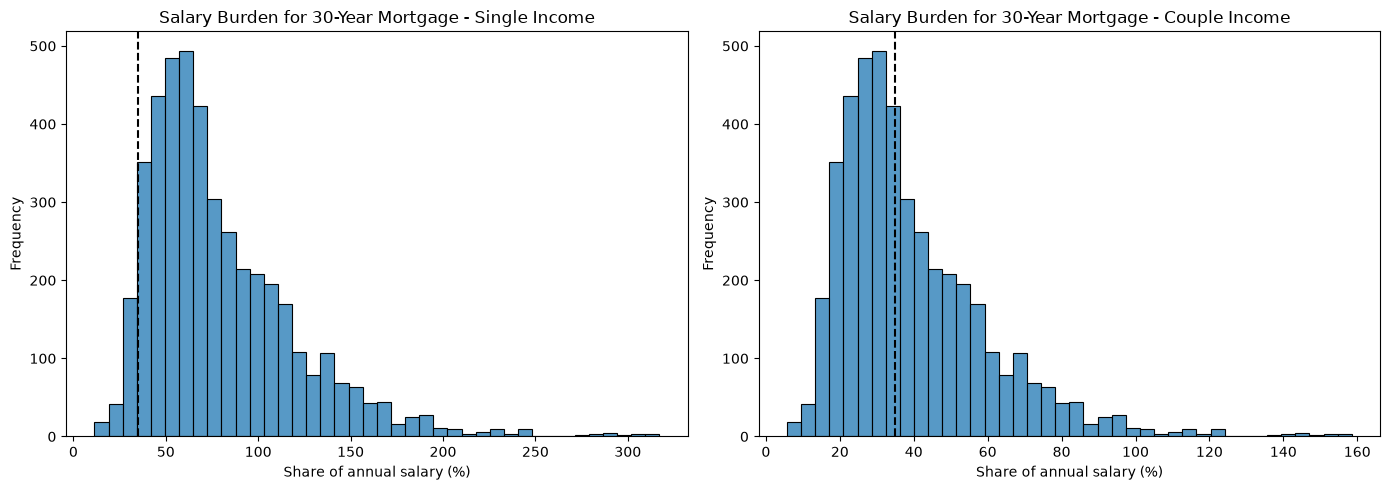

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(gdf_flats_with_salaries["salary_burden_30y"].dropna() * 100,bins=40,ax=axes[0])

axes[0].axvline(DEFAULT_MORTGAGE_ASSUMPTIONS["affordability_threshold"] * 100,linestyle="--",color="black")

axes[0].set_title("Salary Burden for 30-Year Mortgage - Single Income")
axes[0].set_xlabel("Share of annual salary (%)")
axes[0].set_ylabel("Frequency")

sns.histplot(gdf_flats_with_salaries["salary_burden_30y_couple"].dropna() * 100,bins=40,ax=axes[1])

axes[1].axvline(DEFAULT_MORTGAGE_ASSUMPTIONS["affordability_threshold"] * 100,linestyle="--",color="black")

axes[1].set_title("Salary Burden for 30-Year Mortgage - Couple Income")
axes[1].set_xlabel("Share of annual salary (%)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The 30-year burden distributions show a clear difference between single-income and couple-income scenarios.

In the single-income case, most listings exceed the 35% affordability threshold by a wide margin. In the couple-income case, the distribution shifts closer to the threshold, with a meaningful share of listings around or below the affordability boundary.

This reinforces the conclusion that a standard 30-year mortgage is generally not affordable for many single-income profiles, while couple-income affordability is more viable but still uneven across the city.

## 10. Affordability maps

The following maps visualize affordability indicators by neighborhood.

The maps use neighborhood-level averages and are intended to support spatial interpretation of affordability pressure.

In [32]:
neighborhood_geometries = fetch_neighborhood_geometries()

neighborhood_geo_affordability = merge_geometries_with_summary(
    geo_df=neighborhood_geometries,
    geo_name_col="nom_barri",
    summary_df=neighborhood_affordability,
    summary_name_col="level8",
)

neighborhood_geo_affordability.shape

(73, 22)

### 10.1 Minimum mortgage years map

In [33]:
mortgage_years_map = create_affordability_choropleth(
    geo_df=neighborhood_geo_affordability,
    value_col="mean_years_mortgage",
    popup_cols=["level8", "mean_years_mortgage", "mean_years_mortgage_couple"],
    caption="Mean minimum mortgage years",
)

mortgage_years_map

### 10.2 30-year salary burden map

In [34]:
salary_burden_map = create_affordability_choropleth(
    geo_df=neighborhood_geo_affordability,
    value_col="mean_salary_burden_couple",
    popup_cols=["level8", "mean_salary_burden", "mean_salary_burden_couple"],
    caption="Mean salary burden for 30-year mortgage - couple income",
)

salary_burden_map

## 11. Save map outputs

In [35]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

mortgage_years_map.save(FIGURES_DIR / "mortgage_years_map.html")
salary_burden_map.save(FIGURES_DIR / "salary_burden_map.html")

## 12. Module summary

This module connects Barcelona listing prices with local salary estimates to evaluate housing affordability under explicit mortgage assumptions.

The results show that affordability pressure is substantial across much of the listing market. Under a single-income scenario, the average minimum mortgage duration is around 62 years, and the average 30-year salary burden is close to 80% of annual income. These values are well above conventional affordability thresholds.

The couple-income scenario improves affordability significantly, reducing the average minimum mortgage duration to around 36 years and the average salary burden to around 40%. However, affordability remains uneven across neighborhoods and districts.

The analysis also shows that affordability pressure has different drivers depending on the area. In premium districts, high burden is mainly driven by elevated listing prices. In lower-income central areas, affordability pressure can remain high because local salary estimates are comparatively low.

The main takeaway is that housing affordability cannot be assessed using listing prices alone. A more complete view requires combining price levels, local income estimates, financing assumptions, and spatial context.

*Note: This is a simplified scenario model and does not replicate the exact amortization schedule, bank risk assessment, taxes, fees, or lending criteria used in real mortgage approvals.*

## 13. Module output

This module produces:

- listing-level salary estimates based on census-section location
- minimum affordable mortgage duration metrics
- fixed 30-year mortgage burden metrics
- district-level affordability summaries
- neighborhood-level affordability summaries
- neighborhood affordability maps

These outputs complete the affordability scenario analysis and connect listing prices with local income estimates.